<h1>Рубежный контроль №1 по ТМО</h1>
<h2>Афонин Иван ИУ5-62Б</h2>

Задача №1.
Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель. Для студентов групп ИУ5-62Б, ИУ5Ц-82Б - для произвольной колонки данных построить гистограмму.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [2]:
wine = load_wine()

df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Размер датасета:", df.shape)
print("\nНазвания признаков:")
print(wine.feature_names)
print("\nНазвания классов:")
print(wine.target_names)
df.head()

Размер датасета: (178, 14)

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Названия классов:
['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
print("Информация о пропусках в данных:")
print(df.isnull().sum())

print("\nОбщее количество пропусков:", df.isnull().sum().sum())

if df.isnull().sum().sum() > 0:
    print("\nОбнаружены пропуски! Удаляем строки с пропусками...")
    df = df.dropna(axis=0)
else:
    print("\nПропуски в данных отсутствуют. Обработка не требуется.")

Информация о пропусках в данных:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

Общее количество пропусков: 0

Пропуски в данных отсутствуют. Обработка не требуется.


In [4]:
print("Статистическое описание данных:")
df.describe()

Статистическое описание данных:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


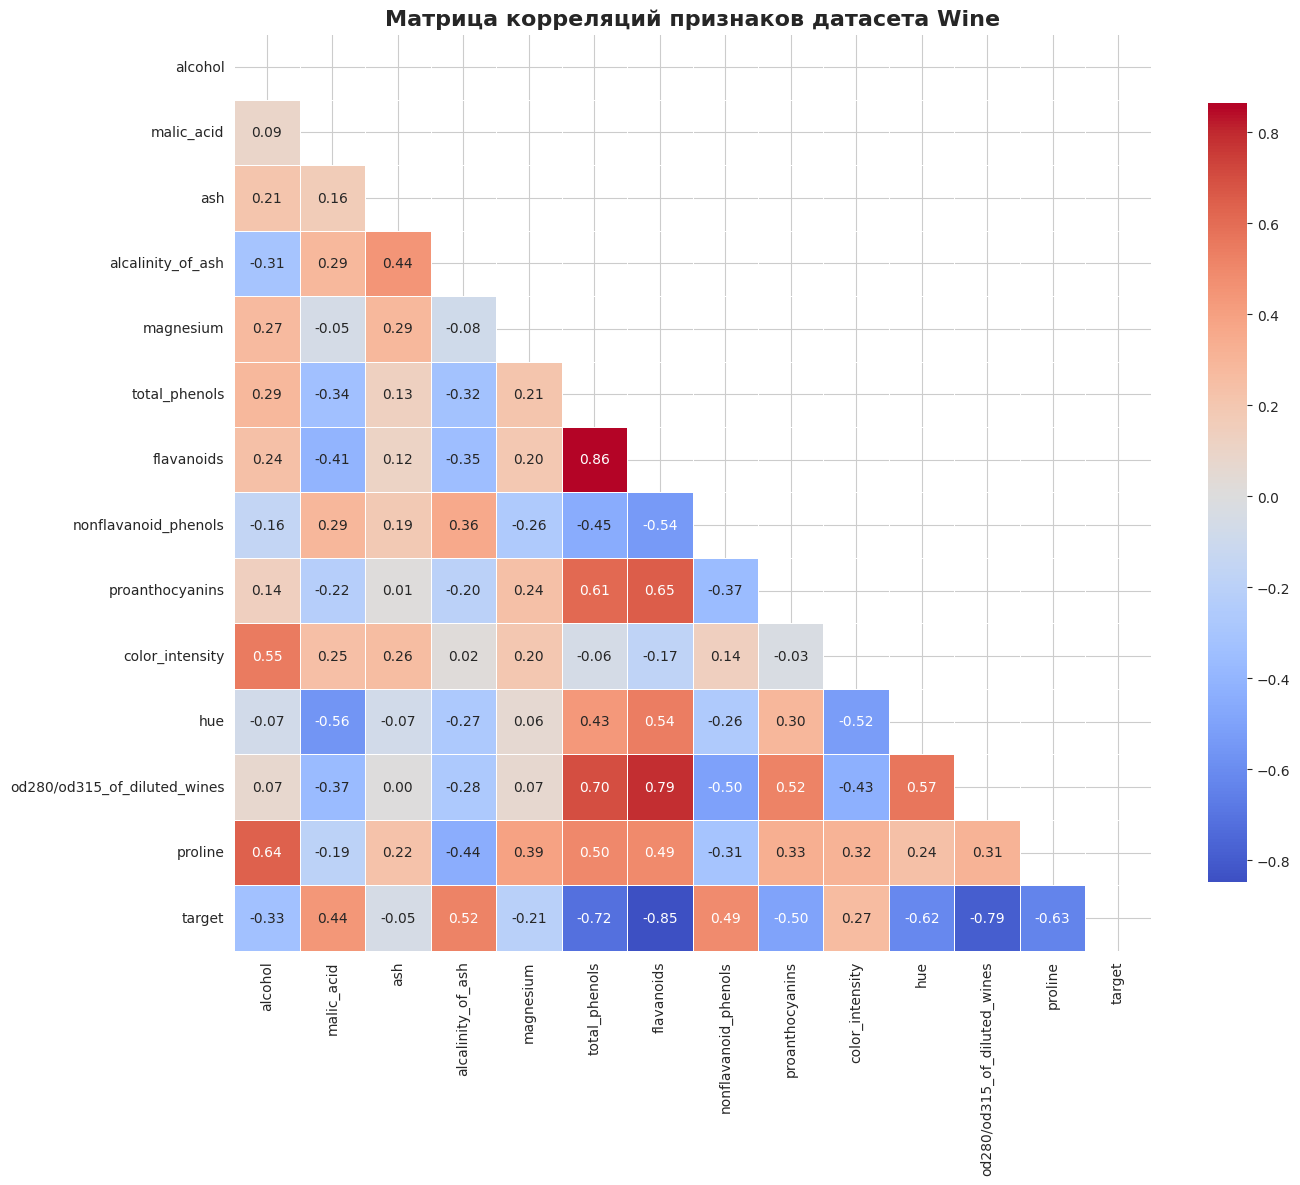

In [5]:
correlation_matrix = df.corr(method='pearson')

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляций признаков датасета Wine', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Признак 1': correlation_matrix.columns[i],
            'Признак 2': correlation_matrix.columns[j],
            'Корреляция': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df = corr_df.sort_values('Корреляция', key=abs, ascending=False)

print("ТОП-10 наиболее сильных корреляций (по модулю):")
corr_df.head(10)

ТОП-10 наиболее сильных корреляций (по модулю):


,Признак 1,Признак 2,Корреляция
55,total_phenols,flavanoids,0.864564
69,flavanoids,target,-0.847498
89,od280/od315_of_diluted_wines,target,-0.788230
67,flavanoids,od280/od315_of_diluted_wines,0.787194
62,total_phenols,target,-0.719163
60,total_phenols,od280/od315_of_diluted_wines,0.699949
64,flavanoids,proanthocyanins,0.652692
11,alcohol,proline,0.643720
90,proline,target,-0.633717
87,hue,target,-0.617369


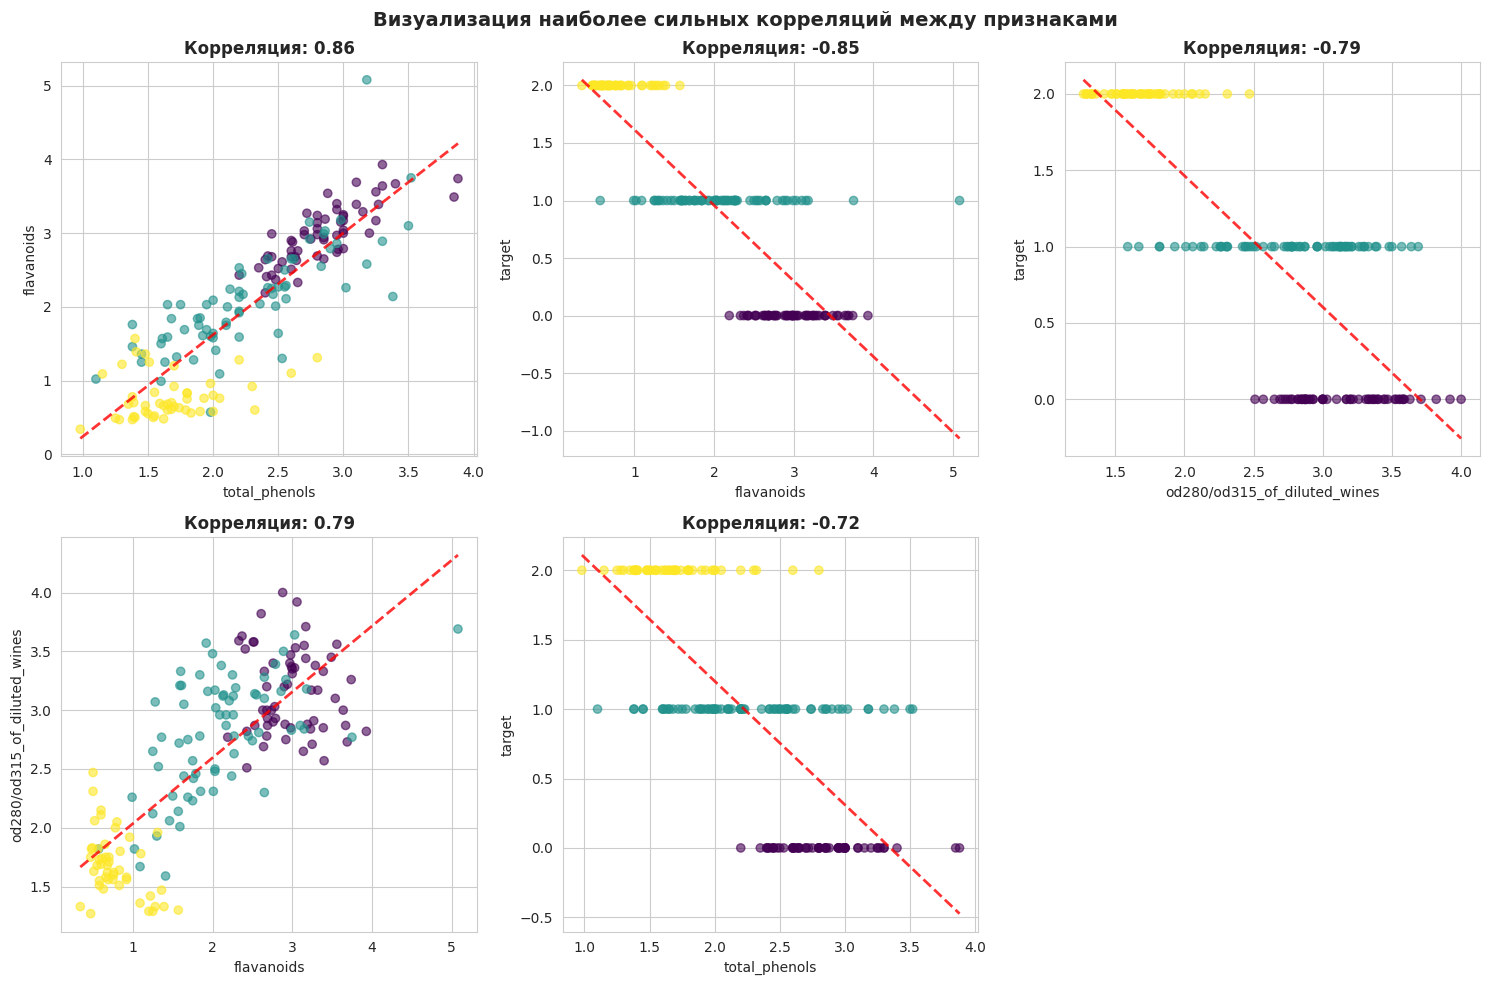

In [7]:
strong_corr_pairs = corr_df.head(5)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (_, row) in enumerate(strong_corr_pairs.iterrows()):
    if idx < 6:
        feature1 = row['Признак 1']
        feature2 = row['Признак 2']
        correlation = row['Корреляция']
        
        axes[idx].scatter(df[feature1], df[feature2], alpha=0.6, c=df['target'], cmap='viridis')
        axes[idx].set_xlabel(feature1, fontsize=10)
        axes[idx].set_ylabel(feature2, fontsize=10)
        axes[idx].set_title(f'Корреляция: {correlation:.2f}', fontsize=12, fontweight='bold')
        
        z = np.polyfit(df[feature1], df[feature2], 1)
        p = np.poly1d(z)
        axes[idx].plot(df[feature1].sort_values(), p(df[feature1].sort_values()), 
                      "r--", alpha=0.8, linewidth=2)

if len(strong_corr_pairs) < 6:
    fig.delaxes(axes[len(strong_corr_pairs)])

plt.suptitle('Визуализация наиболее сильных корреляций между признаками', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

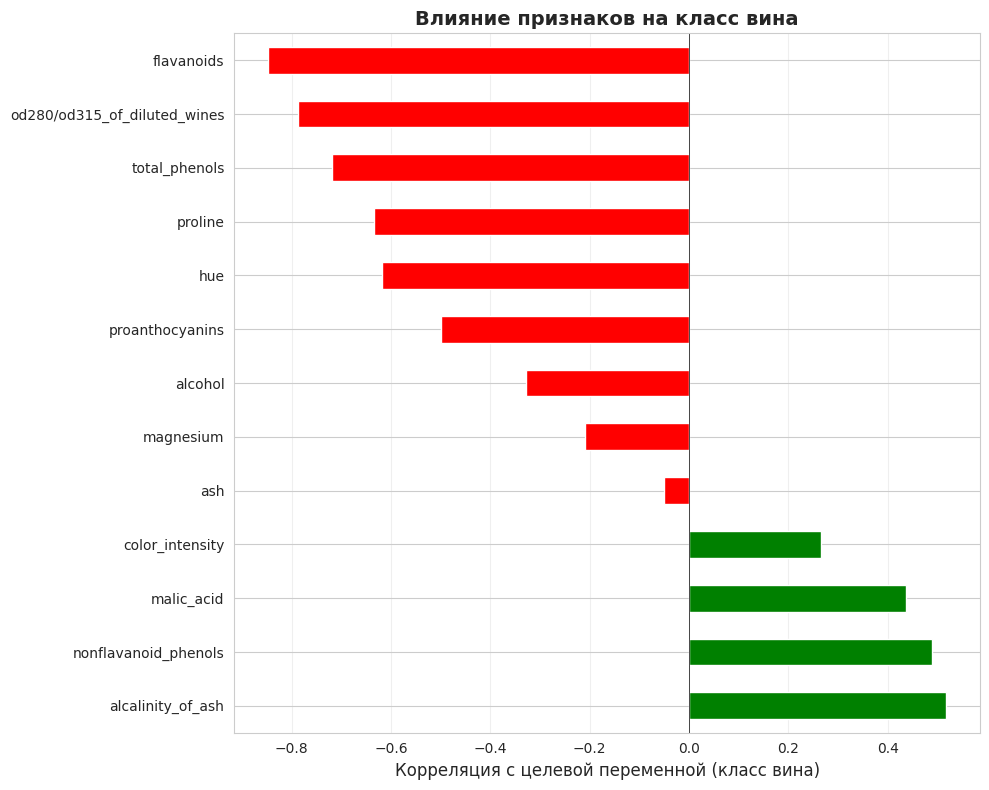


Корреляция признаков с целевой переменной:
alcalinity_of_ash               0.517859
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
color_intensity                 0.265668
ash                            -0.049643
magnesium                      -0.209179
alcohol                        -0.328222
proanthocyanins                -0.499130
hue                            -0.617369
proline                        -0.633717
total_phenols                  -0.719163
od280/od315_of_diluted_wines   -0.788230
flavanoids                     -0.847498
Name: target, dtype: float64


In [8]:
target_corr = correlation_matrix['target'].drop('target').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.xlabel('Корреляция с целевой переменной (класс вина)', fontsize=12)
plt.title('Влияние признаков на класс вина', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nКорреляция признаков с целевой переменной:")
print(target_corr)

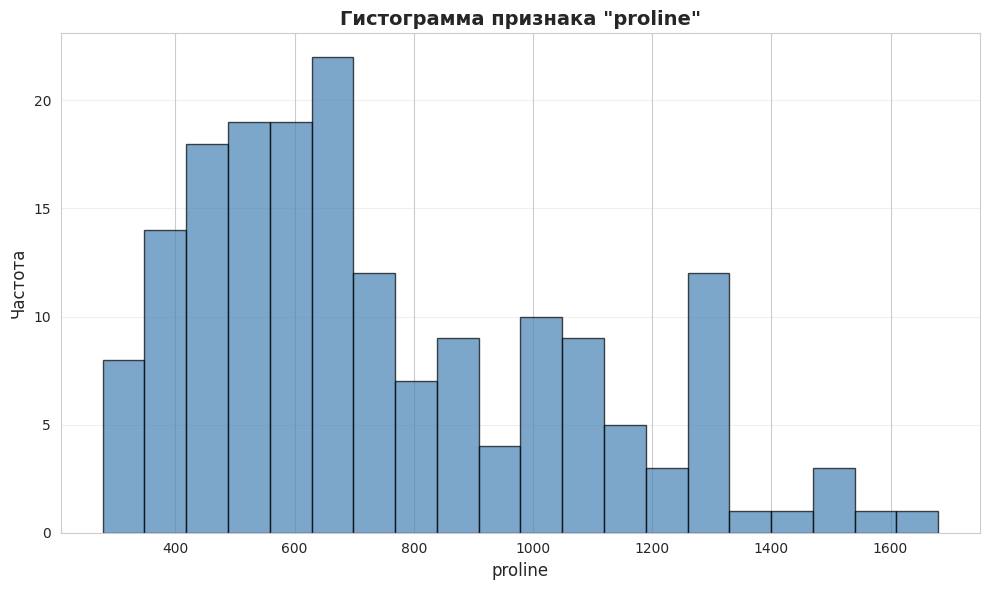

In [12]:
selected_column = 'proline'

plt.figure(figsize=(10, 6))
plt.hist(df[selected_column], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(selected_column, fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title(f'Гистограмма признака "{selected_column}"', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h2>Выводы:</h2>
<p>Данный датасет не содержит пропусков, обладает небольшими размерами, что позволяет быстро обучать разные модели, классы сбалансированы. При этом в нём слишком большой разброс масштабов признаков, поэтому необходима нормализация или стандартизация, также присутствует мультиколлинеарность, что может оказывать негативное влияние. Таким образом, этому датасету лучше всего подойдут методы случайного леса или градиентного бустинга, также можно решать задачу логистической регресии и k-ближайших соседей, но лучше не использовать его при решении задач линейной регресии. Наиболее важными признаками являются flavanoids, proline, color_intensity, но они также сильно коррелируют друг с другом, поэтому нужно внимательно относиться к их выбору.</p>